In [11]:
import os
import shutil
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

## Train/Val Split

In [12]:

SOURCE = "ASL_Digits/asl_dataset_digits"
TRAIN_DIR = "digits_split/train"
VAL_DIR = "digits_split/val"

for digit in [str(i) for i in range(10)]:
    images = os.listdir(os.path.join(SOURCE, digit))
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    os.makedirs(os.path.join(TRAIN_DIR, digit), exist_ok=True)
    os.makedirs(os.path.join(VAL_DIR, digit), exist_ok=True)

    for img in train_imgs:
        shutil.copy(os.path.join(SOURCE, digit, img), os.path.join(TRAIN_DIR, digit, img))
    for img in val_imgs:
        shutil.copy(os.path.join(SOURCE, digit, img), os.path.join(VAL_DIR, digit, img))

print("Split done")

Split done


## Fine Tuning: Mobile Net

### Version 1

In [12]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [13]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('digits_split/train', transform=transform)
val_dataset = datasets.ImageFolder('digits_split/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("Classes:", train_dataset.classes)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train samples: 509, Val samples: 120


In [4]:

model_mobilenet_v1 = timm.create_model('mobilenetv1_100', pretrained=True, num_classes=10)

optimizer_v1 = optim.Adam(model_mobilenet_v1.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet_v1.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_v1.zero_grad()
        outputs = model_mobilenet_v1(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v1.step()
        total_loss += loss.item()

    model_mobilenet_v1.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet_v1(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

Epoch 1: Loss=36.948, Val Accuracy=0.6167
Epoch 2: Loss=2.150, Val Accuracy=0.8500
Epoch 3: Loss=3.872, Val Accuracy=0.9583
Epoch 4: Loss=1.903, Val Accuracy=0.7750
Epoch 5: Loss=1.640, Val Accuracy=0.9500
Epoch 6: Loss=2.317, Val Accuracy=0.9667
Epoch 7: Loss=2.663, Val Accuracy=0.8917
Epoch 8: Loss=4.104, Val Accuracy=0.8667
Epoch 9: Loss=7.352, Val Accuracy=0.9000
Epoch 10: Loss=0.819, Val Accuracy=0.9583
Epoch 11: Loss=0.602, Val Accuracy=1.0000
Epoch 12: Loss=0.150, Val Accuracy=1.0000
Epoch 13: Loss=0.115, Val Accuracy=0.9417
Epoch 14: Loss=0.029, Val Accuracy=1.0000
Epoch 15: Loss=0.100, Val Accuracy=0.9833


### Version 2 

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader


In [6]:

# Load pretrained MobileNetV2, replace final layer for 10 classes
model_mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V1')
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.last_channel, 10)

optimizer = optim.Adam(model_mobilenet.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

# Training loop
EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_mobilenet(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_mobilenet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /Users/arshiya/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:16<00:00, 885kB/s] 


Epoch 1: Loss=40.759, Val Accuracy=0.9917
Epoch 2: Loss=9.836, Val Accuracy=1.0000
Epoch 3: Loss=3.252, Val Accuracy=1.0000
Epoch 4: Loss=3.746, Val Accuracy=1.0000
Epoch 5: Loss=1.405, Val Accuracy=1.0000
Epoch 6: Loss=1.410, Val Accuracy=1.0000
Epoch 7: Loss=1.580, Val Accuracy=1.0000
Epoch 8: Loss=0.903, Val Accuracy=1.0000
Epoch 9: Loss=0.785, Val Accuracy=1.0000
Epoch 10: Loss=0.834, Val Accuracy=1.0000
Epoch 11: Loss=2.916, Val Accuracy=1.0000
Epoch 12: Loss=0.721, Val Accuracy=1.0000
Epoch 13: Loss=1.095, Val Accuracy=1.0000
Epoch 14: Loss=0.684, Val Accuracy=1.0000
Epoch 15: Loss=0.982, Val Accuracy=1.0000


### Version 3

In [7]:
#MobileNetV3-Small:

model_mobilenet_v3_small = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
model_mobilenet_v3_small.classifier[3] = nn.Linear(model_mobilenet_v3_small.classifier[3].in_features, 10)

optimizer_v3s = optim.Adam(model_mobilenet_v3_small.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet_v3_small.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_v3s.zero_grad()
        outputs = model_mobilenet_v3_small(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v3s.step()
        total_loss += loss.item()

    model_mobilenet_v3_small.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet_v3_small(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_mobilenet_v3_small.state_dict()

print(f"\nBest Validation Accuracy (V3-Small): {best_val_acc:.4f}")
model_mobilenet_v3_small.load_state_dict(best_model_state)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /Users/arshiya/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:04<00:00, 2.23MB/s]


Epoch 1: Loss=59.006, Val Accuracy=0.2250
Epoch 2: Loss=37.170, Val Accuracy=0.5083
Epoch 3: Loss=19.493, Val Accuracy=0.7500
Epoch 4: Loss=9.283, Val Accuracy=0.8583
Epoch 5: Loss=4.100, Val Accuracy=0.9250
Epoch 6: Loss=3.448, Val Accuracy=0.9583
Epoch 7: Loss=1.526, Val Accuracy=0.9667
Epoch 8: Loss=1.694, Val Accuracy=0.9917
Epoch 9: Loss=1.489, Val Accuracy=0.9917
Epoch 10: Loss=1.731, Val Accuracy=0.9833
Epoch 11: Loss=1.392, Val Accuracy=0.9917
Epoch 12: Loss=0.764, Val Accuracy=1.0000
Epoch 13: Loss=1.037, Val Accuracy=1.0000
Epoch 14: Loss=0.876, Val Accuracy=1.0000
Epoch 15: Loss=0.607, Val Accuracy=0.9917

Best Validation Accuracy (V3-Small): 1.0000


<All keys matched successfully>

In [8]:
model_mobilenet_v3_large = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
model_mobilenet_v3_large.classifier[3] = nn.Linear(model_mobilenet_v3_large.classifier[3].in_features, 10)

optimizer_v3l = optim.Adam(model_mobilenet_v3_large.parameters(), lr=0.0001)

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet_v3_large.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_v3l.zero_grad()
        outputs = model_mobilenet_v3_large(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v3l.step()
        total_loss += loss.item()

    model_mobilenet_v3_large.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet_v3_large(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_mobilenet_v3_large.state_dict()

print(f"\nBest Validation Accuracy (V3-Large): {best_val_acc:.4f}")
model_mobilenet_v3_large.load_state_dict(best_model_state)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /Users/arshiya/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:09<00:00, 2.24MB/s]


Epoch 1: Loss=51.428, Val Accuracy=0.3083
Epoch 2: Loss=18.161, Val Accuracy=0.8000
Epoch 3: Loss=5.259, Val Accuracy=0.9500
Epoch 4: Loss=2.479, Val Accuracy=0.9833
Epoch 5: Loss=1.675, Val Accuracy=0.9917
Epoch 6: Loss=0.714, Val Accuracy=0.9917
Epoch 7: Loss=1.112, Val Accuracy=1.0000
Epoch 8: Loss=0.814, Val Accuracy=0.9750
Epoch 9: Loss=0.382, Val Accuracy=1.0000
Epoch 10: Loss=0.398, Val Accuracy=1.0000
Epoch 11: Loss=0.476, Val Accuracy=1.0000
Epoch 12: Loss=0.802, Val Accuracy=1.0000
Epoch 13: Loss=0.534, Val Accuracy=1.0000
Epoch 14: Loss=0.557, Val Accuracy=1.0000
Epoch 15: Loss=0.969, Val Accuracy=1.0000

Best Validation Accuracy (V3-Large): 1.0000


<All keys matched successfully>

In [9]:
test_dataset = datasets.ImageFolder('ASL_Digits/test', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

def evaluate_model(model, loader, name):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"{name}: Test Accuracy = {acc:.4f}")
    return acc

results = {}
results['MobileNetV1'] = evaluate_model(model_mobilenet_v1, test_loader, 'MobileNetV1')
results['MobileNetV2'] = evaluate_model(model_mobilenet, test_loader, 'MobileNetV2')
results['MobileNetV3-Small'] = evaluate_model(model_mobilenet_v3_small, test_loader, 'MobileNetV3-Small')
results['MobileNetV3-Large'] = evaluate_model(model_mobilenet_v3_large, test_loader, 'MobileNetV3-Large')

MobileNetV1: Test Accuracy = 0.9923
MobileNetV2: Test Accuracy = 1.0000
MobileNetV3-Small: Test Accuracy = 0.9923
MobileNetV3-Large: Test Accuracy = 0.9923


In [11]:
import cv2

cap = cv2.VideoCapture(0)
count = 0

while True:
    label = input("Enter the digit you're about to sign (or 'quit' to stop): ")
    if label.lower() == 'quit':
        break

    print(f"Signing '{label}' — press 's' to save, 'n' for next digit")
    while True:
        ret, frame = cap.read()
        cv2.imshow('Capture - press s to save, n for next digit', frame)
        key = cv2.waitKey(1)
        if key == ord('s'):
            filename = f"webcam_digit_{label}_{count}.jpg"
            cv2.imwrite(filename, frame)
            print(f"Saved {filename}")
            count += 1
        elif key == ord('n'):
            break

cap.release()
cv2.destroyAllWindows()

Signing '0' — press 's' to save, 'n' for next digit
Saved webcam_digit_0_0.jpg
Saved webcam_digit_0_1.jpg
Saved webcam_digit_0_2.jpg
Saved webcam_digit_0_3.jpg
Saved webcam_digit_0_4.jpg
Signing '1' — press 's' to save, 'n' for next digit
Saved webcam_digit_1_5.jpg
Saved webcam_digit_1_6.jpg
Saved webcam_digit_1_7.jpg
Saved webcam_digit_1_8.jpg
Saved webcam_digit_1_9.jpg
Saved webcam_digit_1_10.jpg
Signing '2' — press 's' to save, 'n' for next digit
Saved webcam_digit_2_11.jpg
Saved webcam_digit_2_12.jpg
Saved webcam_digit_2_13.jpg
Saved webcam_digit_2_14.jpg
Saved webcam_digit_2_15.jpg
Saved webcam_digit_2_16.jpg
Signing '3' — press 's' to save, 'n' for next digit
Saved webcam_digit_3_17.jpg
Saved webcam_digit_3_18.jpg
Saved webcam_digit_3_19.jpg
Saved webcam_digit_3_20.jpg
Saved webcam_digit_3_21.jpg
Saved webcam_digit_3_22.jpg
Signing '4' — press 's' to save, 'n' for next digit
Saved webcam_digit_4_23.jpg
Saved webcam_digit_4_24.jpg
Saved webcam_digit_4_25.jpg
Saved webcam_digit_4_2

In [12]:
import glob
from PIL import Image

def predict_webcam_digit(img_path, model, transform):
    image = Image.open(img_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
    return test_dataset.classes[predicted.item()]

webcam_images = glob.glob('webcam_digit_*.jpg')
print(f"Found {len(webcam_images)} webcam images")

models_to_test = {
    'MobileNetV1': model_mobilenet_v1,
    'MobileNetV2': model_mobilenet,
    'MobileNetV3-Small': model_mobilenet_v3_small,
    'MobileNetV3-Large': model_mobilenet_v3_large
}

for model_name, model in models_to_test.items():
    correct = 0
    total = 0
    for img_path in webcam_images:
        true_label = img_path.split('_')[2]
        pred_label = predict_webcam_digit(img_path, model, transform)
        total += 1
        if pred_label == true_label:
            correct += 1
    print(f"{model_name}: Webcam Accuracy = {correct}/{total} = {correct/total:.2%}")

Found 58 webcam images
MobileNetV1: Webcam Accuracy = 10/58 = 17.24%
MobileNetV2: Webcam Accuracy = 8/58 = 13.79%
MobileNetV3-Small: Webcam Accuracy = 8/58 = 13.79%
MobileNetV3-Large: Webcam Accuracy = 7/58 = 12.07%


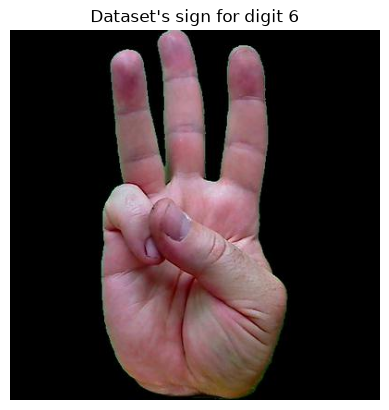

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

digit_to_check = '6'  # try a few — 6,7,8,9 have more sign variation across systems
sample_folder = f'ASL_Digits/asl_dataset_digits/{digit_to_check}'
sample_img = os.listdir(sample_folder)[0]

img = Image.open(os.path.join(sample_folder, sample_img))
plt.imshow(img)
plt.title(f"Dataset's sign for digit {digit_to_check}")
plt.axis('off')
plt.show()

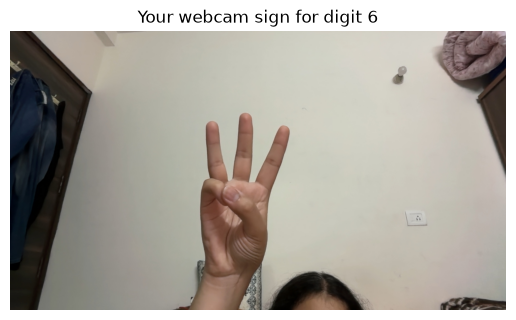

In [15]:
img2 = Image.open('webcam_digit_6_34.jpg')  # adjust filename to one of your actual captures
plt.imshow(img2)
plt.title("Your webcam sign for digit 6")
plt.axis('off')
plt.show()


In [17]:
new_webcam_images = glob.glob('webcam_digit_v2_*.jpg')
print(f"Found {len(new_webcam_images)} clean-background images")

models_to_test = {
    'MobileNetV1': model_mobilenet_v1,
    'MobileNetV2': model_mobilenet,
    'MobileNetV3-Small': model_mobilenet_v3_small,
    'MobileNetV3-Large': model_mobilenet_v3_large
}

for model_name, model in models_to_test.items():
    correct = 0
    total = 0
    for img_path in new_webcam_images:
        true_label = img_path.split('_')[3]  # note: index 3 now, since filename has extra "v2" part
        pred_label = predict_webcam_digit(img_path, model, transform)
        total += 1
        if pred_label == true_label:
            correct += 1
    print(f"{model_name}: Clean-background Accuracy = {correct}/{total} = {correct/total:.2%}")

Found 59 clean-background images
MobileNetV1: Clean-background Accuracy = 18/59 = 30.51%
MobileNetV2: Clean-background Accuracy = 9/59 = 15.25%
MobileNetV3-Small: Clean-background Accuracy = 3/59 = 5.08%
MobileNetV3-Large: Clean-background Accuracy = 6/59 = 10.17%


### Capturing images to be added in the training dataset

In [16]:
import cv2

cap = cv2.VideoCapture(0)
count = 0

while True:
    label = input("Enter the digit you're about to sign (or 'quit' to stop): ")
    if label.lower() == 'quit':
        break

    print(f"Signing '{label}' — press 's' to save, 'n' for next digit")
    while True:
        ret, frame = cap.read()
        cv2.imshow('Capture - press s to save, n for next digit', frame)
        key = cv2.waitKey(1)
        if key == ord('s'):
            filename = f"webcam_digit_v2_{label}_{count}.jpg"
            cv2.imwrite(filename, frame)
            print(f"Saved {filename}")
            count += 1
        elif key == ord('n'):
            break

cap.release()
cv2.destroyAllWindows()

Signing '0' — press 's' to save, 'n' for next digit
Saved webcam_digit_v2_0_0.jpg
Saved webcam_digit_v2_0_1.jpg
Saved webcam_digit_v2_0_2.jpg
Saved webcam_digit_v2_0_3.jpg
Saved webcam_digit_v2_0_4.jpg
Saved webcam_digit_v2_0_5.jpg
Signing '1' — press 's' to save, 'n' for next digit
Saved webcam_digit_v2_1_6.jpg
Saved webcam_digit_v2_1_7.jpg
Saved webcam_digit_v2_1_8.jpg
Saved webcam_digit_v2_1_9.jpg
Saved webcam_digit_v2_1_10.jpg
Saved webcam_digit_v2_1_11.jpg
Signing '2' — press 's' to save, 'n' for next digit
Saved webcam_digit_v2_2_12.jpg
Saved webcam_digit_v2_2_13.jpg
Saved webcam_digit_v2_2_14.jpg
Saved webcam_digit_v2_2_15.jpg
Saved webcam_digit_v2_2_16.jpg
Signing '3' — press 's' to save, 'n' for next digit
Saved webcam_digit_v2_3_17.jpg
Saved webcam_digit_v2_3_18.jpg
Saved webcam_digit_v2_3_19.jpg
Saved webcam_digit_v2_3_20.jpg
Saved webcam_digit_v2_3_21.jpg
Saved webcam_digit_v2_3_22.jpg
Signing '4' — press 's' to save, 'n' for next digit
Saved webcam_digit_v2_4_23.jpg
Saved 

In [14]:
import glob
new_images = glob.glob('webcam_digit_v2_*.jpg')
print(f"Found {len(new_images)} new training images")

for img_path in new_images:
    digit = img_path.split('_')[3]
    dest_folder = f'digits_split/train/{digit}'
    os.makedirs(dest_folder, exist_ok=True)
    shutil.copy(img_path, os.path.join(dest_folder, os.path.basename(img_path)))

print("Merged into training folders")

train_dataset = datasets.ImageFolder('digits_split/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
print(f"New train samples: {len(train_dataset)}")

Found 59 new training images
Merged into training folders
New train samples: 509


#### MobileNetV2:


In [16]:
criterion = nn.CrossEntropyLoss()

In [ ]:
model_mobilenet = models.mobilenet_v2(weights='IMAGENET1K_V1')
model_mobilenet.classifier[1] = nn.Linear(model_mobilenet.last_channel, 10)

optimizer = optim.Adam(model_mobilenet.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_mobilenet(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    model_mobilenet.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_mobilenet.state_dict()

model_mobilenet.load_state_dict(best_model_state)
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch 1: Loss=48.625, Val Accuracy=0.9583
Epoch 2: Loss=14.954, Val Accuracy=1.0000
Epoch 3: Loss=5.514, Val Accuracy=1.0000
Epoch 4: Loss=2.441, Val Accuracy=1.0000
Epoch 5: Loss=1.383, Val Accuracy=1.0000
Epoch 6: Loss=0.837, Val Accuracy=1.0000
Epoch 7: Loss=0.546, Val Accuracy=1.0000
Epoch 8: Loss=0.482, Val Accuracy=1.0000
Epoch 9: Loss=0.371, Val Accuracy=1.0000
Epoch 10: Loss=0.312, Val Accuracy=1.0000
Epoch 11: Loss=0.348, Val Accuracy=1.0000
Epoch 12: Loss=0.207, Val Accuracy=1.0000
Epoch 13: Loss=0.204, Val Accuracy=1.0000
Epoch 14: Loss=0.196, Val Accuracy=1.0000
Epoch 15: Loss=0.148, Val Accuracy=1.0000
Best Validation Accuracy: 1.0000


#### MobileNetV1:

In [21]:
model_mobilenet_v1 = timm.create_model('mobilenetv1_100', pretrained=True, num_classes=10)
optimizer_v1 = optim.Adam(model_mobilenet_v1.parameters(), lr=0.0001)

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet_v1.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_v1.zero_grad()
        outputs = model_mobilenet_v1(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v1.step()
        total_loss += loss.item()

    model_mobilenet_v1.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet_v1(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_mobilenet_v1.state_dict()

model_mobilenet_v1.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (V1): {best_val_acc:.4f}")

Epoch 1: Loss=50.579, Val Accuracy=0.6833
Epoch 2: Loss=8.014, Val Accuracy=0.7833
Epoch 3: Loss=3.910, Val Accuracy=0.7500
Epoch 4: Loss=2.309, Val Accuracy=0.9667
Epoch 5: Loss=1.771, Val Accuracy=0.9083
Epoch 6: Loss=1.474, Val Accuracy=0.9250
Epoch 7: Loss=0.723, Val Accuracy=0.9583
Epoch 8: Loss=0.638, Val Accuracy=1.0000
Epoch 9: Loss=0.681, Val Accuracy=0.9667
Epoch 10: Loss=1.271, Val Accuracy=0.9500
Epoch 11: Loss=1.168, Val Accuracy=0.9833
Epoch 12: Loss=0.851, Val Accuracy=0.9917
Epoch 13: Loss=1.158, Val Accuracy=0.8750
Epoch 14: Loss=0.557, Val Accuracy=0.9583
Epoch 15: Loss=1.113, Val Accuracy=0.8250
Best Validation Accuracy (V1): 1.0000


#### MobileNetV3-Small:

In [22]:
model_mobilenet_v3_small = models.mobilenet_v3_small(weights='IMAGENET1K_V1')
model_mobilenet_v3_small.classifier[3] = nn.Linear(model_mobilenet_v3_small.classifier[3].in_features, 10)
optimizer_v3s = optim.Adam(model_mobilenet_v3_small.parameters(), lr=0.0001)

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet_v3_small.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_v3s.zero_grad()
        outputs = model_mobilenet_v3_small(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v3s.step()
        total_loss += loss.item()

    model_mobilenet_v3_small.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet_v3_small(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_mobilenet_v3_small.state_dict()

model_mobilenet_v3_small.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (V3-Small): {best_val_acc:.4f}")

Epoch 1: Loss=63.851, Val Accuracy=0.3667
Epoch 2: Loss=40.568, Val Accuracy=0.6333
Epoch 3: Loss=23.240, Val Accuracy=0.9167
Epoch 4: Loss=12.124, Val Accuracy=0.9083
Epoch 5: Loss=8.102, Val Accuracy=0.9667
Epoch 6: Loss=4.025, Val Accuracy=0.9667
Epoch 7: Loss=3.127, Val Accuracy=0.9917
Epoch 8: Loss=2.080, Val Accuracy=0.9917
Epoch 9: Loss=1.456, Val Accuracy=1.0000
Epoch 10: Loss=1.187, Val Accuracy=1.0000
Epoch 11: Loss=0.809, Val Accuracy=1.0000
Epoch 12: Loss=0.794, Val Accuracy=1.0000
Epoch 13: Loss=0.513, Val Accuracy=1.0000
Epoch 14: Loss=0.424, Val Accuracy=1.0000
Epoch 15: Loss=0.345, Val Accuracy=1.0000
Best Validation Accuracy (V3-Small): 1.0000


#### MobileNetV3-Large:

In [23]:
model_mobilenet_v3_large = models.mobilenet_v3_large(weights='IMAGENET1K_V1')
model_mobilenet_v3_large.classifier[3] = nn.Linear(model_mobilenet_v3_large.classifier[3].in_features, 10)
optimizer_v3l = optim.Adam(model_mobilenet_v3_large.parameters(), lr=0.0001)

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_mobilenet_v3_large.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_v3l.zero_grad()
        outputs = model_mobilenet_v3_large(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_v3l.step()
        total_loss += loss.item()

    model_mobilenet_v3_large.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_mobilenet_v3_large(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_mobilenet_v3_large.state_dict()

model_mobilenet_v3_large.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (V3-Large): {best_val_acc:.4f}")

Epoch 1: Loss=56.078, Val Accuracy=0.3833
Epoch 2: Loss=21.905, Val Accuracy=0.7500
Epoch 3: Loss=7.950, Val Accuracy=0.8583
Epoch 4: Loss=4.006, Val Accuracy=0.8667
Epoch 5: Loss=1.796, Val Accuracy=0.9333
Epoch 6: Loss=0.793, Val Accuracy=0.9833
Epoch 7: Loss=0.500, Val Accuracy=0.9917
Epoch 8: Loss=0.515, Val Accuracy=1.0000
Epoch 9: Loss=0.312, Val Accuracy=1.0000
Epoch 10: Loss=0.470, Val Accuracy=1.0000
Epoch 11: Loss=0.252, Val Accuracy=1.0000
Epoch 12: Loss=0.241, Val Accuracy=1.0000
Epoch 13: Loss=0.608, Val Accuracy=1.0000
Epoch 14: Loss=1.068, Val Accuracy=1.0000
Epoch 15: Loss=0.205, Val Accuracy=1.0000
Best Validation Accuracy (V3-Large): 1.0000


In [24]:
original_webcam_images = [f for f in glob.glob('webcam_digit_*.jpg') if 'v2' not in f]
print(f"Testing on {len(original_webcam_images)} original webcam images")

models_to_test = {
    'MobileNetV1': model_mobilenet_v1,
    'MobileNetV2': model_mobilenet,
    'MobileNetV3-Small': model_mobilenet_v3_small,
    'MobileNetV3-Large': model_mobilenet_v3_large
}

final_results = {}
for model_name, model in models_to_test.items():
    correct = 0
    total = 0
    for img_path in original_webcam_images:
        true_label = img_path.split('_')[2]
        pred_label = predict_webcam_digit(img_path, model, transform)
        total += 1
        if pred_label == true_label:
            correct += 1
    acc = correct / total
    final_results[model_name] = acc
    print(f"{model_name} (retrained): Real Webcam Accuracy = {correct}/{total} = {acc:.2%}")

Testing on 58 original webcam images
MobileNetV1 (retrained): Real Webcam Accuracy = 31/58 = 53.45%
MobileNetV2 (retrained): Real Webcam Accuracy = 38/58 = 65.52%
MobileNetV3-Small (retrained): Real Webcam Accuracy = 24/58 = 41.38%
MobileNetV3-Large (retrained): Real Webcam Accuracy = 41/58 = 70.69%


## EfficientNet

In [28]:
test_dataset = datasets.ImageFolder('ASL_Digits/test', transform=transform)

### EfficientNet-B0

In [25]:
model_efficientnet_b0 = models.efficientnet_b0(weights='IMAGENET1K_V1')
model_efficientnet_b0.classifier[1] = nn.Linear(model_efficientnet_b0.classifier[1].in_features, 10)

optimizer_eff = optim.Adam(model_efficientnet_b0.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_efficientnet_b0.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_eff.zero_grad()
        outputs = model_efficientnet_b0(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_eff.step()
        total_loss += loss.item()

    model_efficientnet_b0.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_efficientnet_b0(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_efficientnet_b0.state_dict()

model_efficientnet_b0.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (EfficientNet-B0): {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/arshiya/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:09<00:00, 2.30MB/s]


Epoch 1: Loss=64.773, Val Accuracy=0.9333
Epoch 2: Loss=37.974, Val Accuracy=0.9833
Epoch 3: Loss=21.493, Val Accuracy=0.9917
Epoch 4: Loss=13.241, Val Accuracy=0.9917
Epoch 5: Loss=8.230, Val Accuracy=1.0000
Epoch 6: Loss=5.677, Val Accuracy=1.0000
Epoch 7: Loss=3.941, Val Accuracy=1.0000
Epoch 8: Loss=2.843, Val Accuracy=1.0000
Epoch 9: Loss=1.621, Val Accuracy=1.0000
Epoch 10: Loss=1.605, Val Accuracy=1.0000
Epoch 11: Loss=1.218, Val Accuracy=1.0000
Epoch 12: Loss=1.225, Val Accuracy=1.0000
Epoch 13: Loss=0.796, Val Accuracy=1.0000
Epoch 14: Loss=0.711, Val Accuracy=1.0000
Epoch 15: Loss=0.881, Val Accuracy=1.0000
Best Validation Accuracy (EfficientNet-B0): 1.0000


### EfficientNetV2-Small:

In [17]:
model_efficientnet_v2s = models.efficientnet_v2_s(weights='IMAGENET1K_V1')
model_efficientnet_v2s.classifier[1] = nn.Linear(model_efficientnet_v2s.classifier[1].in_features, 10)

optimizer_effv2 = optim.Adam(model_efficientnet_v2s.parameters(), lr=0.0001)

best_val_acc = 0
best_model_state = None

EPOCHS = 10
for epoch in range(EPOCHS):
    model_efficientnet_v2s.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_effv2.zero_grad()
        outputs = model_efficientnet_v2s(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_effv2.step()
        total_loss += loss.item()

    model_efficientnet_v2s.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_efficientnet_v2s(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_efficientnet_v2s.state_dict()

model_efficientnet_v2s.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (EfficientNetV2-Small): {best_val_acc:.4f}")

Epoch 1: Loss=57.992, Val Accuracy=0.9667
Epoch 2: Loss=21.720, Val Accuracy=1.0000
Epoch 3: Loss=8.896, Val Accuracy=1.0000
Epoch 4: Loss=3.943, Val Accuracy=1.0000
Epoch 5: Loss=2.941, Val Accuracy=1.0000
Epoch 6: Loss=2.376, Val Accuracy=1.0000
Epoch 7: Loss=1.718, Val Accuracy=1.0000
Epoch 8: Loss=1.337, Val Accuracy=1.0000
Epoch 9: Loss=1.182, Val Accuracy=1.0000
Epoch 10: Loss=0.533, Val Accuracy=1.0000
Best Validation Accuracy (EfficientNetV2-Small): 1.0000


## YOLO

In [18]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/arshiya/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [19]:

model_yolo = YOLO('yolov8n-cls.pt')  # nano classification model, pretrained on ImageNet

results = model_yolo.train(
    data='digits_split',  # expects train/ and val/ subfolders, which you already have
    epochs=15,
    imgsz=224,
    batch=16,
    verbose=True
)

Ultralytics 8.4.110 🚀 Python-3.11.15 torch-2.13.0 CPU (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=digits_split, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=

In [22]:
correct = 0
total = 0

for img_path in original_webcam_images:
    true_label = img_path.split('_')[2]
    results = model_yolo(img_path, verbose=False)
    pred_idx = results[0].probs.top1
    pred_label = model_yolo.names[pred_idx]
    total += 1
    if pred_label == true_label:
        correct += 1

print(f"YOLOv8n-cls: Real Webcam Accuracy = {correct}/{total} = {correct/total:.2%}")

YOLOv8n-cls: Real Webcam Accuracy = 51/58 = 87.93%


In [27]:
print(dir())

['DataLoader', 'EPOCHS', 'Image', 'In', 'Out', 'YOLO', '_', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'best_model_state', 'best_val_acc', 'correct', 'criterion', 'cv2', 'datasets', 'dest_folder', 'digit', 'epoch', 'exit', 'final_results', 'get_ipython', 'glob', 'img_path', 'imgs', 'labels', 'loss', 'model_efficientnet_v2s', 'model_yolo', 'models', 'new_images', 'nn', 'np', 'open', 'optim', 'optimizer_effv2', 'original_webcam_images', 'os', 'outputs', 'pd', 'pred_idx', 'pred_label', 'predict_webcam_digit', 'predicted', 'quit', 'results', 'shutil', 'timm', 'torch', 'total', 'total_loss', 'train_dataset', 'train_loader', 'train_test_split', 'transform', 'tra

## Feature-Extraction Method

In [29]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch

model_feature_extract = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze all existing (backbone/hidden) layers
for param in model_feature_extract.parameters():
    param.requires_grad = False

# Replace the final classification layer — only this gets trained
model_feature_extract.classifier[1] = nn.Linear(model_feature_extract.last_channel, 10)

optimizer_fe = optim.Adam(model_feature_extract.classifier[1].parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_feature_extract.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_fe.zero_grad()
        outputs = model_feature_extract(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_fe.step()
        total_loss += loss.item()

    model_feature_extract.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_feature_extract(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_feature_extract.state_dict()

model_feature_extract.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (Feature Extraction, MobileNetV2): {best_val_acc:.4f}")

Epoch 1: Loss=61.680, Val Accuracy=0.7083
Epoch 2: Loss=39.066, Val Accuracy=0.7583
Epoch 3: Loss=29.990, Val Accuracy=0.8750
Epoch 4: Loss=23.807, Val Accuracy=0.8750
Epoch 5: Loss=19.387, Val Accuracy=0.9417
Epoch 6: Loss=16.256, Val Accuracy=0.9500
Epoch 7: Loss=14.741, Val Accuracy=0.9500
Epoch 8: Loss=13.289, Val Accuracy=0.9583
Epoch 9: Loss=12.340, Val Accuracy=0.9583
Epoch 10: Loss=11.627, Val Accuracy=0.9583
Epoch 11: Loss=9.972, Val Accuracy=0.9583
Epoch 12: Loss=8.937, Val Accuracy=0.9750
Epoch 13: Loss=9.581, Val Accuracy=0.9583
Epoch 14: Loss=7.988, Val Accuracy=0.9500
Epoch 15: Loss=7.411, Val Accuracy=0.9667
Best Validation Accuracy (Feature Extraction, MobileNetV2): 0.9750


In [30]:
correct = 0
total = 0
for img_path in original_webcam_images:
    true_label = img_path.split('_')[2]
    pred_label = predict_webcam_digit(img_path, model_feature_extract, transform)
    total += 1
    if pred_label == true_label:
        correct += 1

print(f"MobileNetV2 (Feature Extraction): Real Webcam Accuracy = {correct}/{total} = {correct/total:.2%}")

MobileNetV2 (Feature Extraction): Real Webcam Accuracy = 19/58 = 32.76%


In [31]:
model_partial = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze everything first
for param in model_partial.parameters():
    param.requires_grad = False

# Unfreeze only the last few feature blocks (not the very early ones)
# MobileNetV2's backbone is in model_partial.features (a sequential list of blocks)
for param in model_partial.features[-4:].parameters():  # last 4 blocks
    param.requires_grad = True

# Replace and unfreeze the final classifier layer too
model_partial.classifier[1] = nn.Linear(model_partial.last_channel, 10)

# Only pass trainable parameters to the optimizer
trainable_params = [p for p in model_partial.parameters() if p.requires_grad]
optimizer_partial = optim.Adam(trainable_params, lr=0.0003)

In [32]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim
import torch

model_partial = models.mobilenet_v2(weights='IMAGENET1K_V1')

# Freeze everything first
for param in model_partial.parameters():
    param.requires_grad = False

# Unfreeze only the last few feature blocks
for param in model_partial.features[-4:].parameters():
    param.requires_grad = True

# Replace and unfreeze the final classifier layer
model_partial.classifier[1] = nn.Linear(model_partial.last_channel, 10)

trainable_params = [p for p in model_partial.parameters() if p.requires_grad]
optimizer_partial = optim.Adam(trainable_params, lr=0.0003)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0
best_model_state = None

EPOCHS = 15
for epoch in range(EPOCHS):
    model_partial.train()
    total_loss = 0
    for imgs, labels in train_loader:
        optimizer_partial.zero_grad()
        outputs = model_partial(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_partial.step()
        total_loss += loss.item()

    model_partial.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            outputs = model_partial(imgs)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}: Loss={total_loss:.3f}, Val Accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model_partial.state_dict()

model_partial.load_state_dict(best_model_state)
print(f"Best Validation Accuracy (Partial Fine-tuning, MobileNetV2): {best_val_acc:.4f}")

Epoch 1: Loss=36.686, Val Accuracy=0.9583
Epoch 2: Loss=7.315, Val Accuracy=1.0000
Epoch 3: Loss=2.094, Val Accuracy=1.0000
Epoch 4: Loss=1.767, Val Accuracy=1.0000
Epoch 5: Loss=0.860, Val Accuracy=1.0000
Epoch 6: Loss=0.453, Val Accuracy=1.0000
Epoch 7: Loss=0.333, Val Accuracy=1.0000
Epoch 8: Loss=0.253, Val Accuracy=1.0000
Epoch 9: Loss=0.170, Val Accuracy=1.0000
Epoch 10: Loss=0.222, Val Accuracy=1.0000
Epoch 11: Loss=0.124, Val Accuracy=1.0000
Epoch 12: Loss=0.134, Val Accuracy=1.0000
Epoch 13: Loss=0.126, Val Accuracy=1.0000
Epoch 14: Loss=0.088, Val Accuracy=1.0000
Epoch 15: Loss=0.054, Val Accuracy=1.0000
Best Validation Accuracy (Partial Fine-tuning, MobileNetV2): 1.0000


In [33]:
correct = 0
total = 0
for img_path in original_webcam_images:
    true_label = img_path.split('_')[2]
    pred_label = predict_webcam_digit(img_path, model_partial, transform)
    total += 1
    if pred_label == true_label:
        correct += 1

print(f"MobileNetV2 (Partial Fine-tuning): Real Webcam Accuracy = {correct}/{total} = {correct/total:.2%}")

MobileNetV2 (Partial Fine-tuning): Real Webcam Accuracy = 28/58 = 48.28%
